In [2]:
!pip install kagglehub

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import os

In [3]:
path = kagglehub.dataset_download("ketangangal/heart-disease-dataset-uci")

print("Dataset path:", path)

# List files inside folder
files = os.listdir(path)
print("Files:", files)

100%|██████████| 9.24k/9.24k [00:00<00:00, 14.2MB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/ketangangal/heart-disease-dataset-uci/versions/1
Files: ['HeartDiseaseTrain-Test.csv']


In [4]:
# Load the CSV (usually only one file inside)
file_path = os.path.join(path, files[0])
df = pd.read_csv(file_path)

df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


In [5]:
# Missing values
print(df.isnull().sum())

# Fill missing values (if any)
df.fillna(df.median(numeric_only=True), inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

print("Shape after cleaning:", df.shape)

age                              0
sex                              0
chest_pain_type                  0
resting_blood_pressure           0
cholestoral                      0
fasting_blood_sugar              0
rest_ecg                         0
Max_heart_rate                   0
exercise_induced_angina          0
oldpeak                          0
slope                            0
vessels_colored_by_flourosopy    0
thalassemia                      0
target                           0
dtype: int64
Shape after cleaning: (302, 14)


In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            302 non-null    int64  
 1   sex                            302 non-null    object 
 2   chest_pain_type                302 non-null    object 
 3   resting_blood_pressure         302 non-null    int64  
 4   cholestoral                    302 non-null    int64  
 5   fasting_blood_sugar            302 non-null    object 
 6   rest_ecg                       302 non-null    object 
 7   Max_heart_rate                 302 non-null    int64  
 8   exercise_induced_angina        302 non-null    object 
 9   oldpeak                        302 non-null    float64
 10  slope                          302 non-null    object 
 11  vessels_colored_by_flourosopy  302 non-null    object 
 12  thalassemia                    302 non-null    object 


,age,resting_blood_pressure,cholestoral,Max_heart_rate,oldpeak,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,131.602649,246.500000,149.569536,1.043046,0.543046
std,9.04797,17.563394,51.753489,22.903527,1.161452,0.498970
min,29.00000,94.000000,126.000000,71.000000,0.000000,0.000000
25%,48.00000,120.000000,211.000000,133.250000,0.000000,0.000000
50%,55.50000,130.000000,240.500000,152.500000,0.800000,1.000000
75%,61.00000,140.000000,274.750000,166.000000,1.600000,1.000000
max,77.00000,200.000000,564.000000,202.000000,6.200000,1.000000


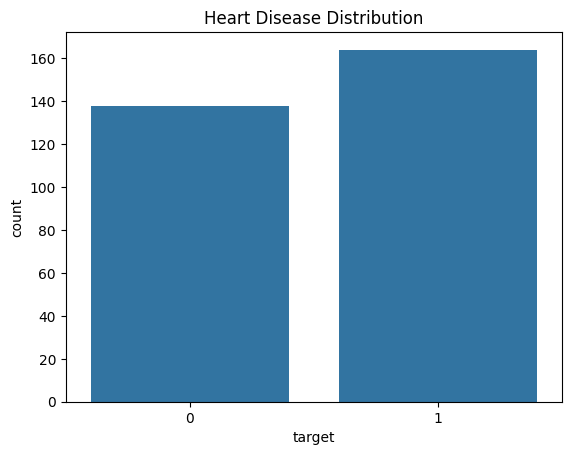

In [7]:
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

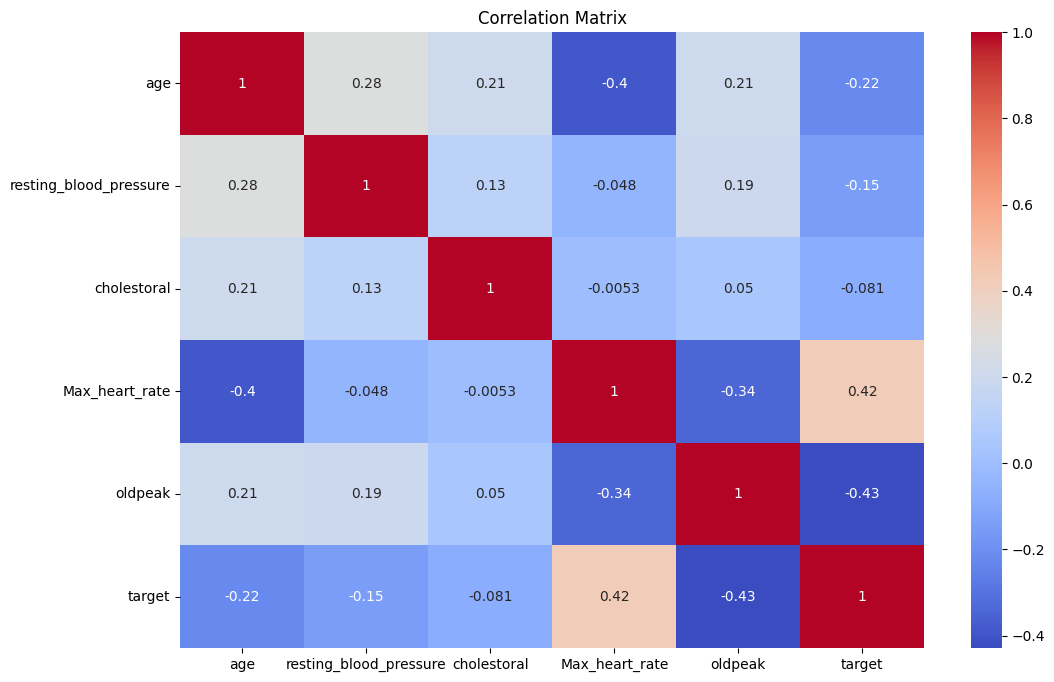

In [9]:

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [10]:
X = df.drop('target', axis=1)
y = df['target']

In [13]:
# Example conversions (adjust if column names differ)
df['sex'] = df['sex'].map({'Male': 1, 'Female': 0})

In [14]:
# Convert all object (string) columns automatically
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = pd.factorize(df[col])[0]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

In [20]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [21]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Logistic Regression Accuracy: 0.7377049180327869
Decision Tree Accuracy: 0.6557377049180327


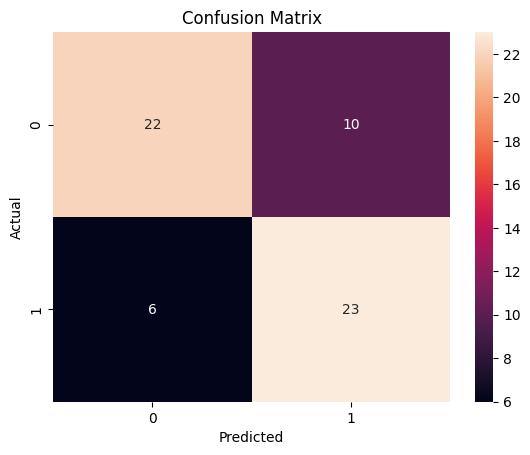

In [22]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

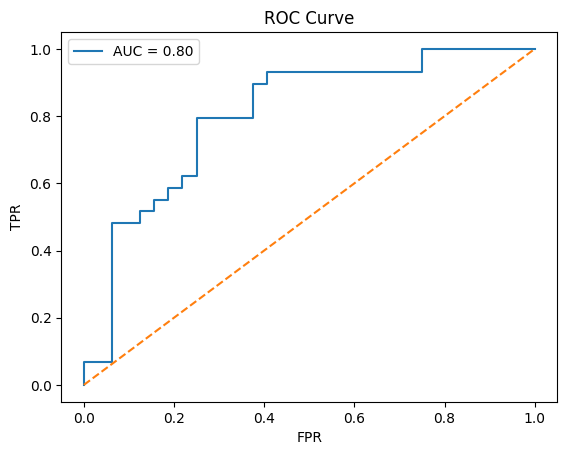

In [23]:
y_prob = lr_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [24]:
importance = lr_model.coef_[0]

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feat_imp)

                          Feature  Importance
2                 chest_pain_type    1.072037
7                  Max_heart_rate    0.447804
12                    thalassemia    0.406181
4                     cholestoral   -0.110083
0                             age   -0.115305
5             fasting_blood_sugar   -0.132521
8         exercise_induced_angina   -0.228706
10                          slope   -0.257079
11  vessels_colored_by_flourosopy   -0.283159
6                        rest_ecg   -0.491830
3          resting_blood_pressure   -0.537180
9                         oldpeak   -0.868894
1                             sex   -0.920297


In [25]:
dt_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(dt_imp)

                          Feature  Importance
2                 chest_pain_type    0.317983
9                         oldpeak    0.143267
4                     cholestoral    0.100371
0                             age    0.092975
11  vessels_colored_by_flourosopy    0.082604
7                  Max_heart_rate    0.077231
3          resting_blood_pressure    0.069444
1                             sex    0.036939
12                    thalassemia    0.031437
5             fasting_blood_sugar    0.019960
6                        rest_ecg    0.012631
8         exercise_induced_angina    0.008421
10                          slope    0.006737


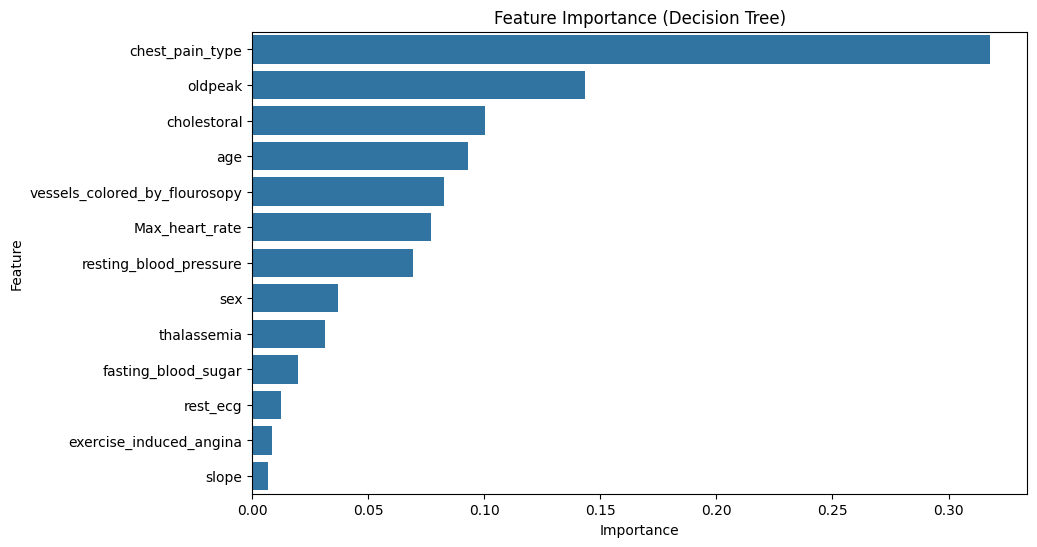

In [26]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=dt_imp)
plt.title("Feature Importance (Decision Tree)")
plt.show()